In [11]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/benin-malanville.csv',parse_dates=['Timestamp'])

In [3]:
df.tail()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
525595,2022-08-08 23:56:00,-5.5,-0.1,-5.9,0.0,0.0,23.1,98.3,0.3,1.1,0.5,119.3,4.1,996,0,0.0,23.5,22.9,NaN
525596,2022-08-08 23:57:00,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.3,0.2,0.7,0.4,115.2,2.3,996,0,0.0,23.5,22.9,NaN
525597,2022-08-08 23:58:00,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.4,0.6,1.1,0.5,129.8,3.4,996,0,0.0,23.5,22.9,NaN
525598,2022-08-08 23:59:00,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.3,0.9,1.3,0.5,124.4,4.3,996,0,0.0,23.5,22.9,NaN
525599,2022-08-09 00:00:00,-5.5,-0.1,-5.7,0.0,0.0,23.1,98.3,1.2,1.6,0.3,124.1,5.9,996,0,0.0,23.5,22.9,NaN


In [4]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-02-07 12:00:30.000000512,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
min,2021-08-09 00:01:00,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,2021-11-08 06:00:45,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,2022-02-07 12:00:30,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,2022-05-09 18:00:15,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,2022-08-09 00:00:00,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN
std,NaN,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN


In [5]:
df.isna().value_counts()

Timestamp  GHI    DNI    DHI    ModA   ModB   Tamb   RH     WS     WSgust  WSstdev  WD     WDstdev  BP     Cleaning  Precipitation  TModA  TModB  Comments
False      False  False  False  False  False  False  False  False  False   False    False  False    False  False     False          False  False  True        525600
Name: count, dtype: int64

In [6]:
print("--- Summary Statistics of Numeric Columns ---")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns in the DataFrame:", numeric_cols)

--- Summary Statistics of Numeric Columns ---
Numeric columns in the DataFrame: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']


In [7]:
print("\n--- Summary Statistics of Numeric Columns ---")
print(df[numeric_cols].describe())


--- Summary Statistics of Numeric Columns ---
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000     

In [8]:
missing_values = df.isna().sum()

In [10]:
threshold = 0.05 * len(df)
high_null_columns = missing_values[missing_values > threshold]
high_null_columns

Comments    525600
dtype: int64

In [ ]:
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

z_scores = df[cols_to_check].apply(zscore)

outliers = (np.abs(z_scores) > 3).any(axis=1)
outlier_df = df[outliers]


In [13]:
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

In [19]:
country = 'benin-malanville'
df.to_csv(f'data/{country}_clean.csv', index=False)

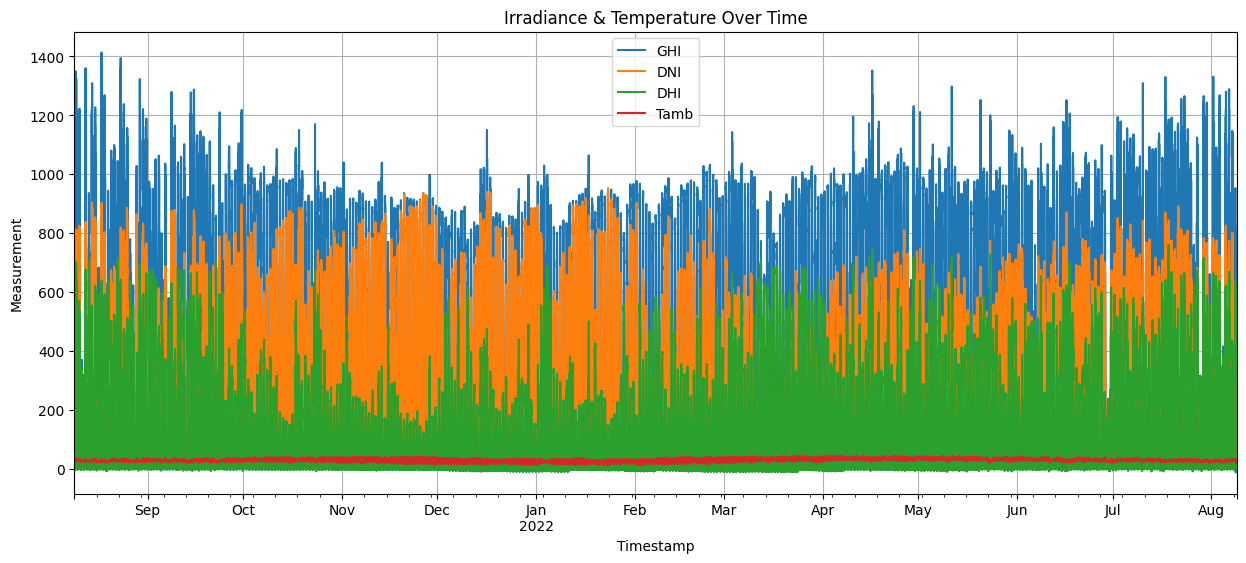

In [20]:
time_cols = ['GHI', 'DNI', 'DHI', 'Tamb']

df.set_index('Timestamp')[time_cols].plot(figsize=(15, 6), title="Irradiance & Temperature Over Time")
plt.ylabel("Measurement")
plt.grid()
plt.show()

<Axes: title={'center': 'Monthly Averages of Solar & Temp'}, xlabel='Month'>

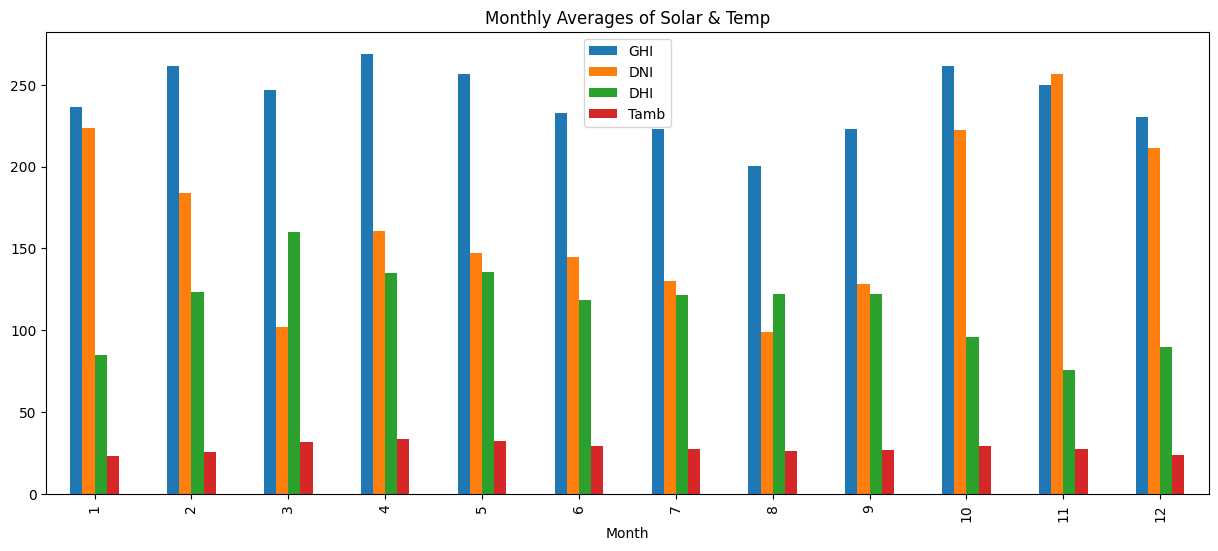

In [21]:
df['Month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('Month')[time_cols].mean()
monthly_avg.plot(kind='bar', figsize=(15, 6), title="Monthly Averages of Solar & Temp")


Text(0, 0.5, 'Sensor Output')

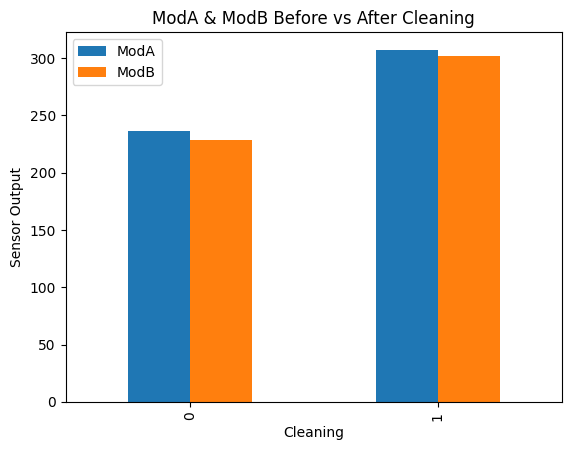

In [22]:
df['Cleaning'] = df['Cleaning'].fillna('Unknown')
cleaning_effect = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

cleaning_effect.plot(kind='bar', title='ModA & ModB Before vs After Cleaning')
plt.ylabel('Sensor Output')

Text(0.5, 1.0, 'Correlation Heatmap')

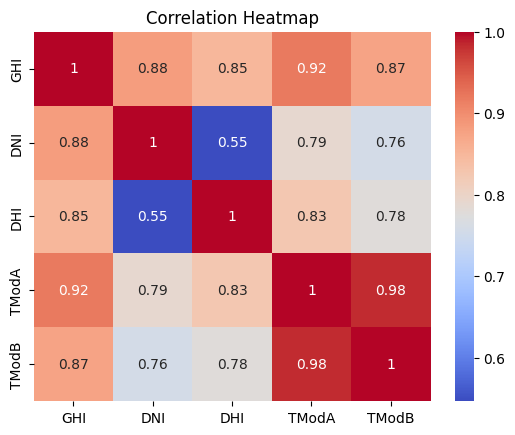

In [23]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
correlation = df[corr_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'RH vs Tamb')

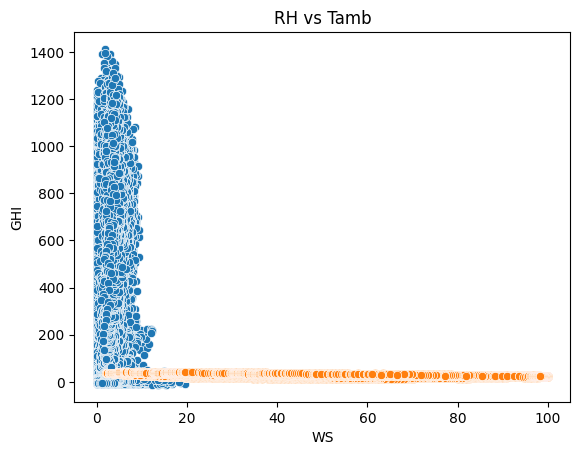

In [24]:
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title('Wind Speed vs GHI')

sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title('RH vs Tamb')

Text(0.5, 1.0, 'Wind Direction Distribution')

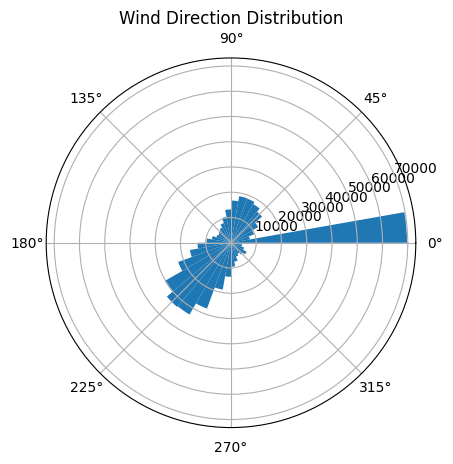

In [25]:
ax = plt.subplot(111, polar=True)
wd_rad = np.radians(df['WD'].dropna())
ax.hist(wd_rad, bins=36)
plt.title("Wind Direction Distribution")

Text(0.5, 0, 'WS')

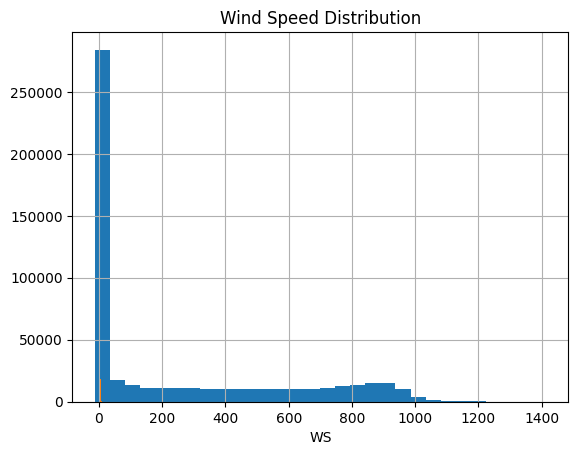

In [26]:
df['GHI'].hist(bins=30)
plt.title('GHI Distribution')
plt.xlabel('GHI')

df['WS'].hist(bins=30)
plt.title('Wind Speed Distribution')
plt.xlabel('WS')

Text(0.5, 1.0, 'RH vs GHI Colored by Tamb')

C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


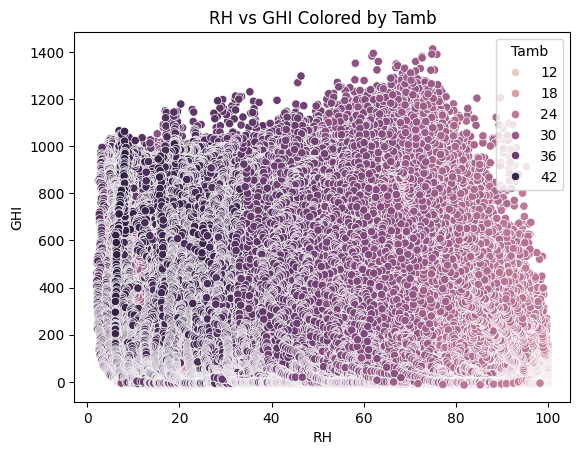

In [27]:
sns.scatterplot(x='RH', y='GHI', hue='Tamb', data=df)
plt.title('RH vs GHI Colored by Tamb')

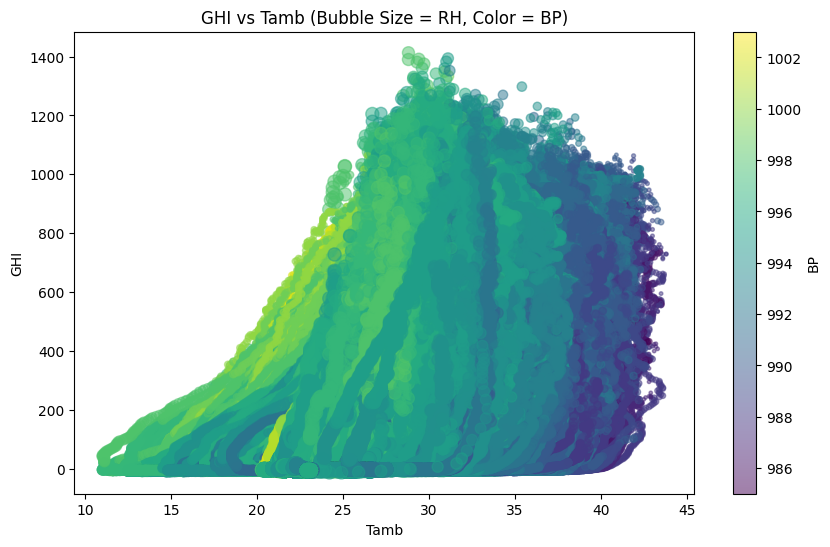

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Tamb'], df['GHI'], s=df['RH'], alpha=0.5, c=df['BP'], cmap='viridis')
plt.xlabel('Tamb')
plt.ylabel('GHI')
plt.title('GHI vs Tamb (Bubble Size = RH, Color = BP)')
plt.colorbar(label='BP')